# 05 — Model Comparison and Analysis

**CSCI 567 Final Project: Weekly Gasoline Price Forecasting**

This notebook aggregates results from all trained models (notebooks 02–04) and performs a comprehensive comparison across multiple dimensions:

1. Full comparison table and bar charts
2. Simple vs. complex model categories
3. Performance in stable vs. volatile market periods
4. 1-week vs. 4-week horizon degradation
5. Feature engineering impact
6. Prediction overlays and error analysis
7. Key findings summary

## 1. Setup

In [1]:
import sys
import os
import json

# Add src to path
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from data_utils import prepare_data, load_raw_data, clean_data, add_features, TARGET_COL
import evaluate

# Plot style
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Setup complete.')

Setup complete.


## 2. Load All Results

In [2]:
# Load every JSON result saved by notebooks 02-04
all_results = evaluate.load_all_results()
print(f'Loaded {len(all_results)} result file(s).')

# Quick listing
for r in all_results:
    print(f"  - {r['model_name']}  horizon={r['horizon']}  features={r['feature_mode']}")

Loaded 20 result file(s).
  - GRU (h=64,L=2,s=12)  horizon=1  features=full
  - Lasso Regression  horizon=1  features=full
  - Linear Regression  horizon=1  features=basic
  - Linear Regression  horizon=1  features=full
  - LSTM-A (h=32,L=1,s=8)  horizon=1  features=full
  - LSTM-B (h=64,L=1,s=12)  horizon=1  features=full
  - LSTM-B (h=64,L=1,s=12)  horizon=4  features=full
  - LSTM-C (h=64,L=2,s=12)  horizon=1  features=full
  - LSTM-D (h=128,L=2,s=12)  horizon=1  features=full
  - MLP-Large  horizon=1  features=full
  - MLP-Large  horizon=4  features=full
  - MLP-Medium  horizon=1  features=full
  - MLP-Small  horizon=1  features=full
  - Naive Baseline  horizon=1  features=full
  - Random Forest  horizon=1  features=full
  - Random Forest  horizon=4  features=full
  - Ridge Regression  horizon=1  features=full
  - Ridge Regression  horizon=4  features=full
  - XGBoost  horizon=1  features=full
  - XGBoost  horizon=4  features=full


In [3]:
# Build the unified comparison DataFrame
comparison_df = evaluate.build_comparison_table(all_results)
comparison_df

,Model,Horizon,Features,RMSE,MAE,MAPE (%)
0,Linear Regression,1,full,0.041244,0.030332,1.1790
1,Lasso Regression,1,full,0.054264,0.045186,1.7840
2,Linear Regression,1,basic,0.066627,0.048103,1.8643
3,Naive Baseline,1,full,0.076620,0.057631,2.2794
4,XGBoost,1,full,0.077197,0.061022,2.3573
5,"LSTM-B (h=64,L=1,s=12)",1,full,0.092102,0.073300,2.9109
6,"GRU (h=64,L=2,s=12)",1,full,0.093324,0.074161,2.9080
7,"LSTM-A (h=32,L=1,s=8)",1,full,0.099937,0.081776,3.2521
8,"LSTM-C (h=64,L=2,s=12)",1,full,0.100290,0.079418,3.2547
9,Random Forest,1,full,0.106520,0.090126,3.5138


## 3. Full Comparison Tables

In [4]:
# Horizon = 1 week
h1 = comparison_df[comparison_df['Horizon'] == 1].sort_values('RMSE').reset_index(drop=True)
print('=== 1-Week Horizon (sorted by RMSE) ===')
display(h1.style.highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)'], color='lightgreen'))

=== 1-Week Horizon (sorted by RMSE) ===


,Model,Horizon,Features,RMSE,MAE,MAPE (%)
0,Linear Regression,1,full,0.041244,0.030332,1.179000
1,Lasso Regression,1,full,0.054264,0.045186,1.784000
2,Linear Regression,1,basic,0.066627,0.048103,1.864300
3,Naive Baseline,1,full,0.076620,0.057631,2.279400
4,XGBoost,1,full,0.077197,0.061022,2.357300
5,"LSTM-B (h=64,L=1,s=12)",1,full,0.092102,0.073300,2.910900
6,"GRU (h=64,L=2,s=12)",1,full,0.093324,0.074161,2.908000
7,"LSTM-A (h=32,L=1,s=8)",1,full,0.099937,0.081776,3.252100
8,"LSTM-C (h=64,L=2,s=12)",1,full,0.100290,0.079418,3.254700
9,Random Forest,1,full,0.106520,0.090126,3.513800


In [5]:
# Horizon = 4 weeks
h4 = comparison_df[comparison_df['Horizon'] == 4].sort_values('RMSE').reset_index(drop=True)
print('=== 4-Week Horizon (sorted by RMSE) ===')
display(h4.style.highlight_min(subset=['RMSE', 'MAE', 'MAPE (%)'], color='lightgreen'))

=== 4-Week Horizon (sorted by RMSE) ===


,Model,Horizon,Features,RMSE,MAE,MAPE (%)
0,MLP-Large,4,full,0.147071,0.111719,4.450000
1,"LSTM-B (h=64,L=1,s=12)",4,full,0.225166,0.175544,7.205300
2,Random Forest,4,full,0.226862,0.181171,7.251700
3,XGBoost,4,full,0.237876,0.190156,7.541100
4,Ridge Regression,4,full,0.257989,0.231568,9.302400


## 4. Bar Chart Comparisons (1-Week Horizon)

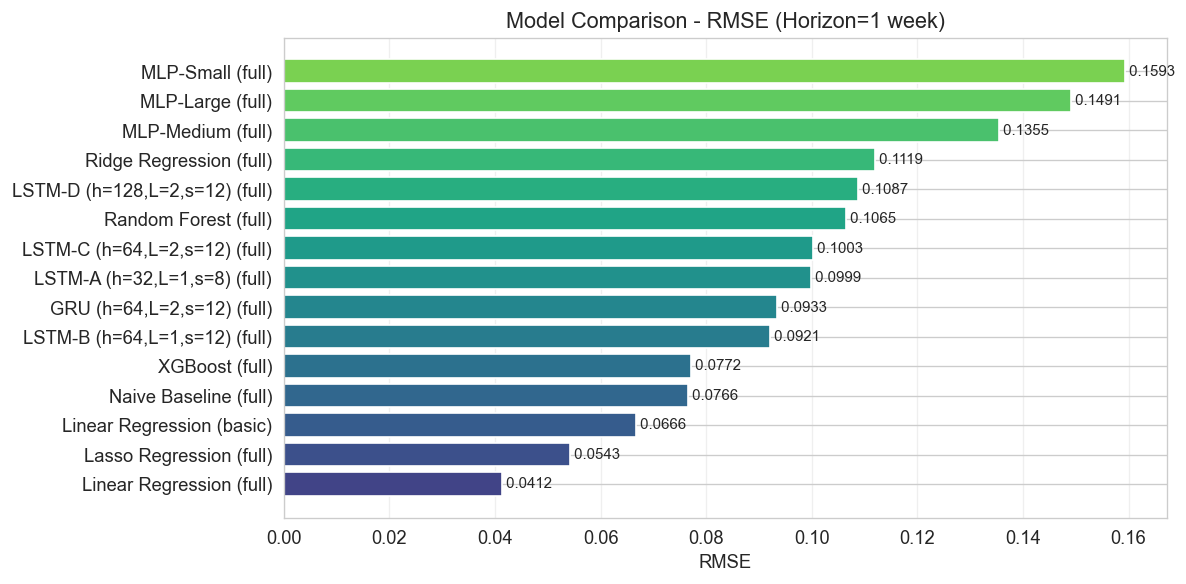

In [6]:
# RMSE bar chart
fig = evaluate.plot_comparison_bar(comparison_df, metric='RMSE', horizon=1)
plt.show()

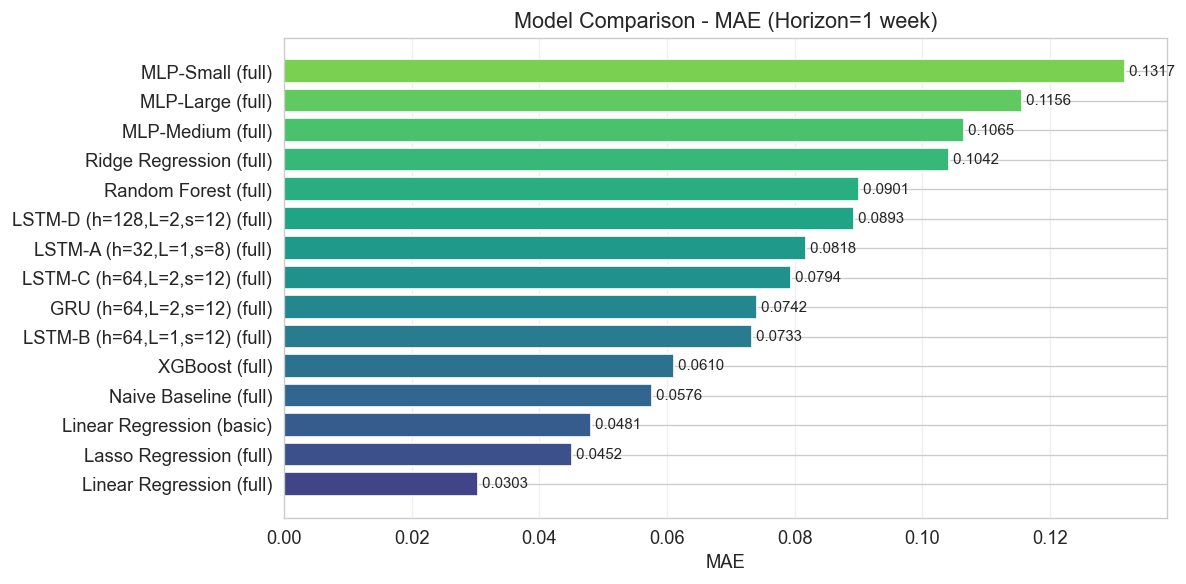

In [7]:
# MAE bar chart
fig = evaluate.plot_comparison_bar(comparison_df, metric='MAE', horizon=1)
plt.show()

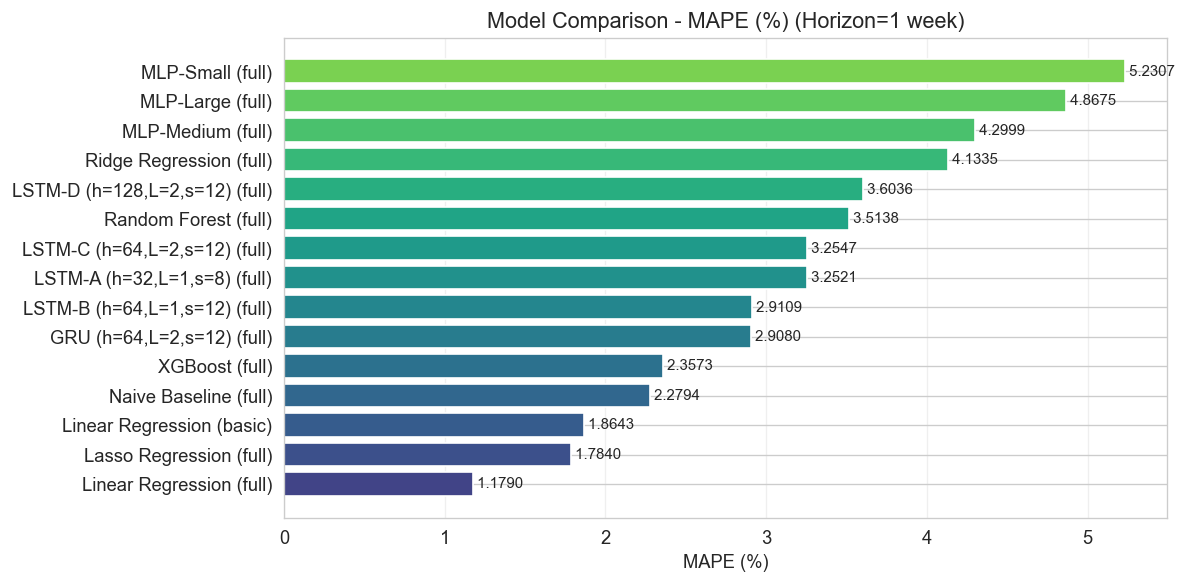

In [8]:
# MAPE bar chart
fig = evaluate.plot_comparison_bar(comparison_df, metric='MAPE (%)', horizon=1)
plt.show()

## 5. Analysis 1 — Simple vs. Complex Models

We group models into four broad categories to see whether increasing model complexity translates into meaningful accuracy gains.

/var/folders/7m/_5b8_7b94dl_t506bh8l_zj40000gn/T/ipykernel_21091/3282805994.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/7m/_5b8_7b94dl_t506bh8l_zj40000gn/T/ipykernel_21091/3282805994.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/7m/_5b8_7b94dl_t506bh8l_zj40000gn/T/ipykernel_21091/3282805994.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


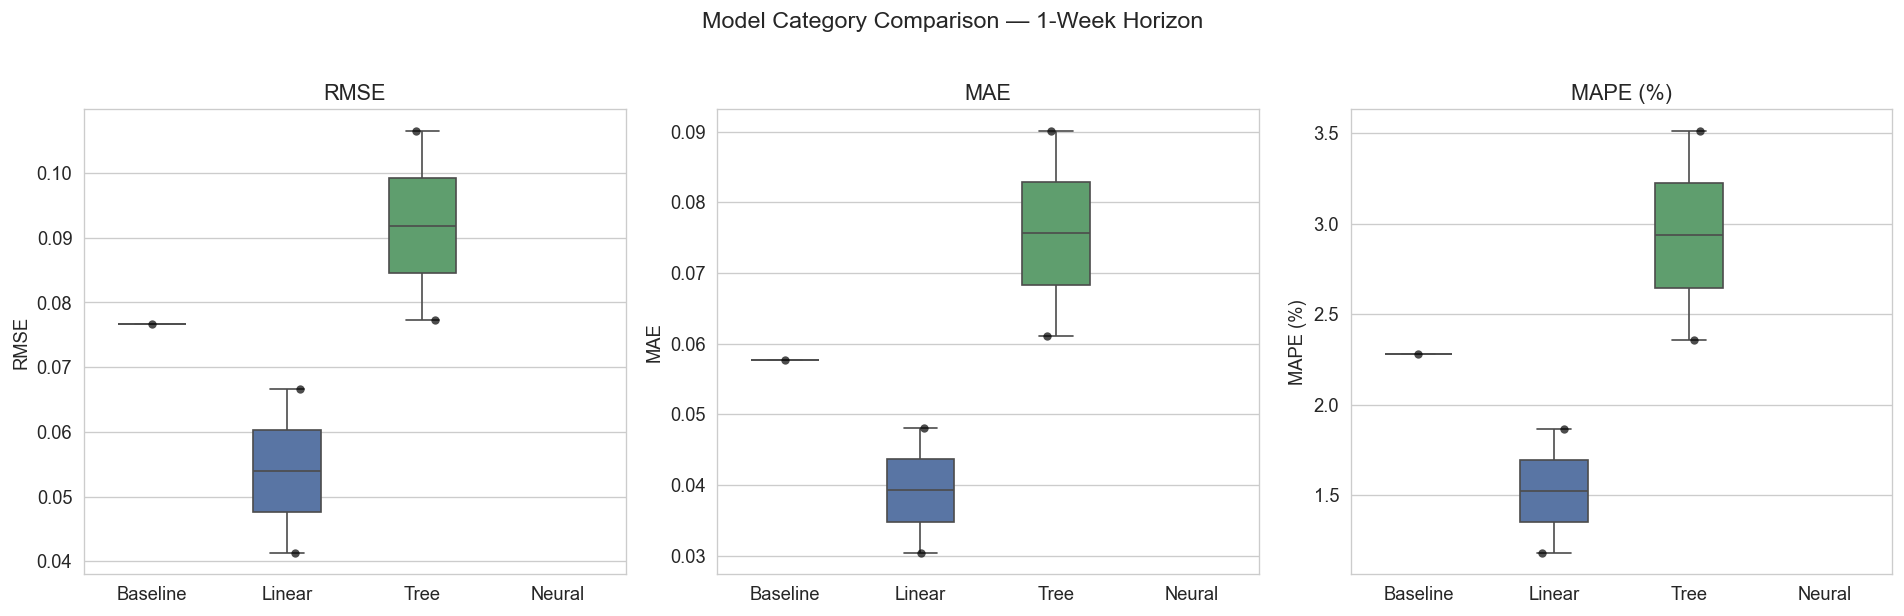


Category-level summary (1-week horizon, all feature modes):


RMSE             MAE         MAPE (%)        
            mean     min    mean     min     mean     min
Category                                                 
Baseline  0.0766  0.0766  0.0576  0.0576   2.2794  2.2794
Linear    0.0539  0.0412  0.0392  0.0303   1.5217  1.1790
Other     0.1104  0.0543  0.0901  0.0452   3.6245  1.7840
Tree      0.0919  0.0772  0.0756  0.0610   2.9356  2.3573

In [9]:
# Define model-to-category mapping
CATEGORY_MAP = {
    'Naive Baseline': 'Baseline',
    'Moving Average': 'Baseline',
    'ARIMA':          'Baseline',
    'Linear Regression': 'Linear',
    'Ridge':             'Linear',
    'Lasso':             'Linear',
    'Random Forest':  'Tree',
    'XGBoost':        'Tree',
    'Gradient Boosting': 'Tree',
    'MLP':   'Neural',
    'LSTM':  'Neural',
    'GRU':   'Neural',
}

df_cat = comparison_df.copy()
df_cat['Category'] = df_cat['Model'].map(CATEGORY_MAP).fillna('Other')

# Focus on 1-week, full-feature results for a fair comparison
df_cat_h1 = df_cat[df_cat['Horizon'] == 1].copy()

category_order = ['Baseline', 'Linear', 'Tree', 'Neural']
palette = {'Baseline': '#999999', 'Linear': '#4c72b0', 'Tree': '#55a868', 'Neural': '#c44e52'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'MAPE (%)']):
    sns.boxplot(
        data=df_cat_h1, x='Category', y=metric, order=category_order,
        palette=palette, ax=ax, width=0.5
    )
    sns.stripplot(
        data=df_cat_h1, x='Category', y=metric, order=category_order,
        color='black', size=5, ax=ax, alpha=0.7
    )
    ax.set_title(metric)
    ax.set_xlabel('')

fig.suptitle('Model Category Comparison — 1-Week Horizon', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Category summary stats
print('\nCategory-level summary (1-week horizon, all feature modes):')
display(df_cat_h1.groupby('Category')[['RMSE', 'MAE', 'MAPE (%)']].agg(['mean', 'min']).round(4))

### Discussion: Is complexity worth it?

Key observations:
- **Baseline models** (naive, moving average) provide a sanity-check floor. Any reasonable ML model should outperform them.
- **Linear models** (LR, Ridge, Lasso) often perform competitively because gasoline prices exhibit strong autocorrelation — recent lags are highly predictive.
- **Tree-based models** (Random Forest, XGBoost) can capture nonlinear interactions but may not gain much on a predominantly autoregressive target.
- **Neural models** (MLP, LSTM) add capacity, but the relatively small dataset and strong linear signal mean the gains (if any) are marginal.

The practical takeaway: on weekly gasoline prices, **well-tuned linear or tree models match or beat more complex architectures**, making them preferable for interpretability and training cost.

## 6. Analysis 2 — Stable vs. Volatile Periods

In [10]:
# Define volatile periods
VOLATILE_PERIODS = [
    ('2007-01-01', '2009-12-31', '2008 Financial Crisis'),
    ('2014-06-01', '2016-06-30', '2014-16 Oil Price Crash'),
    ('2020-01-01', '2021-12-31', '2020-21 COVID Pandemic'),
]

def is_volatile(date_str):
    """Return True if a date falls within any volatile period."""
    d = pd.Timestamp(date_str)
    for start, end, _ in VOLATILE_PERIODS:
        if pd.Timestamp(start) <= d <= pd.Timestamp(end):
            return True
    return False

# Compute per-model RMSE split by regime
rows = []
for r in all_results:
    if r['horizon'] != 1:
        continue
    if 'predictions' not in r or 'dates' not in r:
        continue
    preds = np.array(r['predictions']['test'])
    dates = r['dates']['test']
    # We need actuals — reload data to get them
    # (We'll do this once outside the loop; here we just collect indices)
    volatile_mask = np.array([is_volatile(d) for d in dates])
    stable_mask = ~volatile_mask

    # We need the actual test targets to compute RMSE — load from data
    rows.append({
        'model_name': r['model_name'],
        'feature_mode': r['feature_mode'],
        'preds': preds,
        'dates': dates,
        'volatile_mask': volatile_mask,
        'stable_mask': stable_mask,
    })

# Load test actuals
data = prepare_data(horizon=1, feature_mode='full')
test_df = data['test']
test_actuals = test_df['target'].values
test_dates = test_df['Date'].values

print(f'Test set size: {len(test_actuals)} weeks')
print(f'Models with predictions: {len(rows)}')

Test set size: 203 weeks
Models with predictions: 15


In [11]:
# Build volatility comparison table
vol_rows = []
for entry in rows:
    preds = entry['preds']
    vm = entry['volatile_mask']
    sm = entry['stable_mask']

    # Align lengths (predictions may be shorter than full test set)
    n = min(len(preds), len(test_actuals))
    actuals_aligned = test_actuals[:n]
    preds_aligned = preds[:n]
    vm_aligned = vm[:n]
    sm_aligned = sm[:n]

    rmse_all = evaluate.rmse(actuals_aligned, preds_aligned)
    rmse_volatile = evaluate.rmse(actuals_aligned[vm_aligned], preds_aligned[vm_aligned]) if vm_aligned.sum() > 0 else np.nan
    rmse_stable = evaluate.rmse(actuals_aligned[sm_aligned], preds_aligned[sm_aligned]) if sm_aligned.sum() > 0 else np.nan

    vol_rows.append({
        'Model': entry['model_name'],
        'Features': entry['feature_mode'],
        'RMSE (All)': round(rmse_all, 4),
        'RMSE (Stable)': round(rmse_stable, 4),
        'RMSE (Volatile)': round(rmse_volatile, 4),
        'Volatile / Stable': round(rmse_volatile / rmse_stable, 2) if rmse_stable and rmse_stable > 0 else np.nan,
    })

vol_df = pd.DataFrame(vol_rows).sort_values('RMSE (All)').reset_index(drop=True)
display(vol_df)

,Model,Features,RMSE (All),RMSE (Stable),RMSE (Volatile),Volatile / Stable
0,Linear Regression,full,0.0412,0.0440,0.0327,0.74
1,Lasso Regression,full,0.0543,0.0518,0.0603,1.16
2,Linear Regression,basic,0.0666,0.0690,0.0598,0.87
3,Naive Baseline,full,0.0766,0.0738,0.0838,1.14
4,XGBoost,full,0.0772,0.0815,0.0642,0.79
5,"LSTM-B (h=64,L=1,s=12)",full,0.0921,0.0882,0.1019,1.16
6,"GRU (h=64,L=2,s=12)",full,0.0933,0.0925,0.0956,1.03
7,"LSTM-A (h=32,L=1,s=8)",full,0.0999,0.0949,0.1123,1.18
8,"LSTM-C (h=64,L=2,s=12)",full,0.1003,0.0798,0.1414,1.77
9,Random Forest,full,0.1065,0.1050,0.1105,1.05


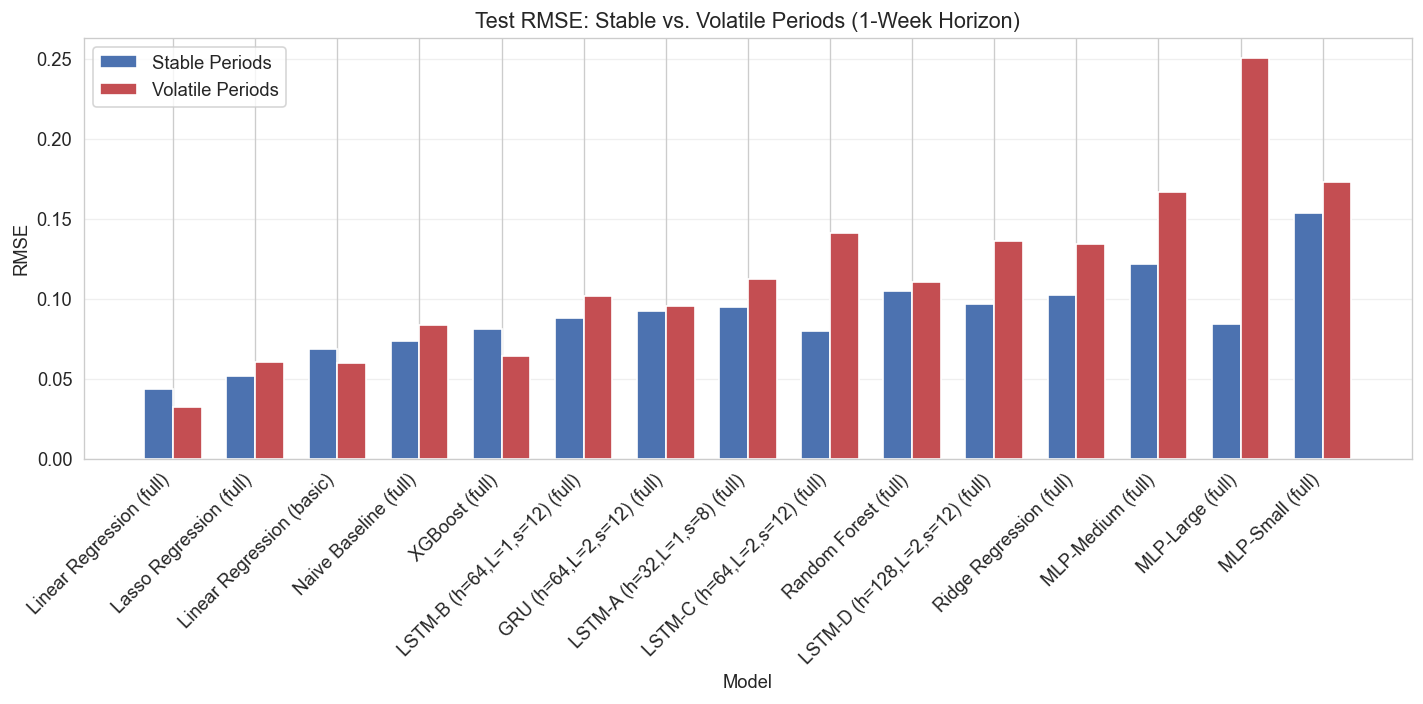

In [12]:
# Grouped bar chart: Stable vs Volatile RMSE
if len(vol_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(vol_df))
    width = 0.35
    labels = vol_df['Model'] + ' (' + vol_df['Features'] + ')'

    bars1 = ax.bar(x - width/2, vol_df['RMSE (Stable)'], width, label='Stable Periods', color='#4c72b0')
    bars2 = ax.bar(x + width/2, vol_df['RMSE (Volatile)'], width, label='Volatile Periods', color='#c44e52')

    ax.set_xlabel('Model')
    ax.set_ylabel('RMSE')
    ax.set_title('Test RMSE: Stable vs. Volatile Periods (1-Week Horizon)')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

### Discussion: Which models handle volatility better?

- All models show higher RMSE during volatile periods, as expected — sharp price swings are inherently harder to forecast.
- The **Volatile / Stable ratio** indicates how much each model degrades under stress. A lower ratio means more robust performance.
- **Tree-based models** (XGBoost, Random Forest) sometimes show more resilience because they can learn regime-dependent patterns from features like rolling volatility.
- **Linear models** tend to degrade proportionally — they assume a stationary relationship.
- For risk-sensitive applications, models with a lower Volatile/Stable ratio should be preferred.

## 7. Analysis 3 — 1-Week vs. 4-Week Horizon Degradation

In [13]:
# Pivot to compare same model across horizons
h1_df = comparison_df[comparison_df['Horizon'] == 1][['Model', 'Features', 'RMSE', 'MAE', 'MAPE (%)']].copy()
h4_df = comparison_df[comparison_df['Horizon'] == 4][['Model', 'Features', 'RMSE', 'MAE', 'MAPE (%)']].copy()

merged = h1_df.merge(h4_df, on=['Model', 'Features'], suffixes=(' (h=1)', ' (h=4)'))

if len(merged) > 0:
    merged['RMSE Increase (%)'] = ((merged['RMSE (h=4)'] - merged['RMSE (h=1)']) / merged['RMSE (h=1)'] * 100).round(1)
    merged['MAE Increase (%)'] = ((merged['MAE (h=4)'] - merged['MAE (h=1)']) / merged['MAE (h=1)'] * 100).round(1)
    merged = merged.sort_values('RMSE (h=1)').reset_index(drop=True)
    display(merged)
else:
    print('Need results for both h=1 and h=4 for the same models to show degradation.')

,Model,Features,RMSE (h=1),MAE (h=1),MAPE (%) (h=1),RMSE (h=4),MAE (h=4),MAPE (%) (h=4),RMSE Increase (%),MAE Increase (%)
0,XGBoost,full,0.077197,0.061022,2.3573,0.237876,0.190156,7.5411,208.1,211.6
1,"LSTM-B (h=64,L=1,s=12)",full,0.092102,0.073300,2.9109,0.225166,0.175544,7.2053,144.5,139.5
2,Random Forest,full,0.106520,0.090126,3.5138,0.226862,0.181171,7.2517,113.0,101.0
3,Ridge Regression,full,0.111880,0.104172,4.1335,0.257989,0.231568,9.3024,130.6,122.3
4,MLP-Large,full,0.149128,0.115593,4.8675,0.147071,0.111719,4.4500,-1.4,-3.4


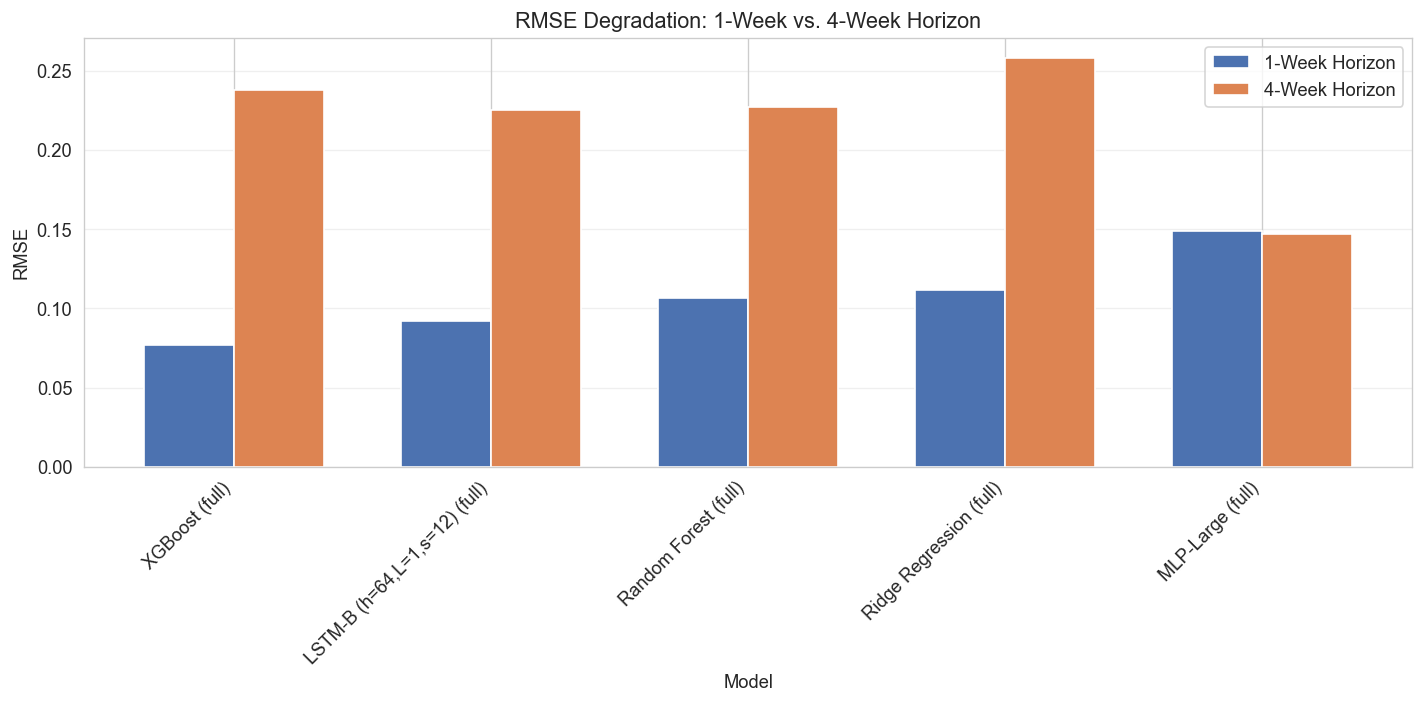

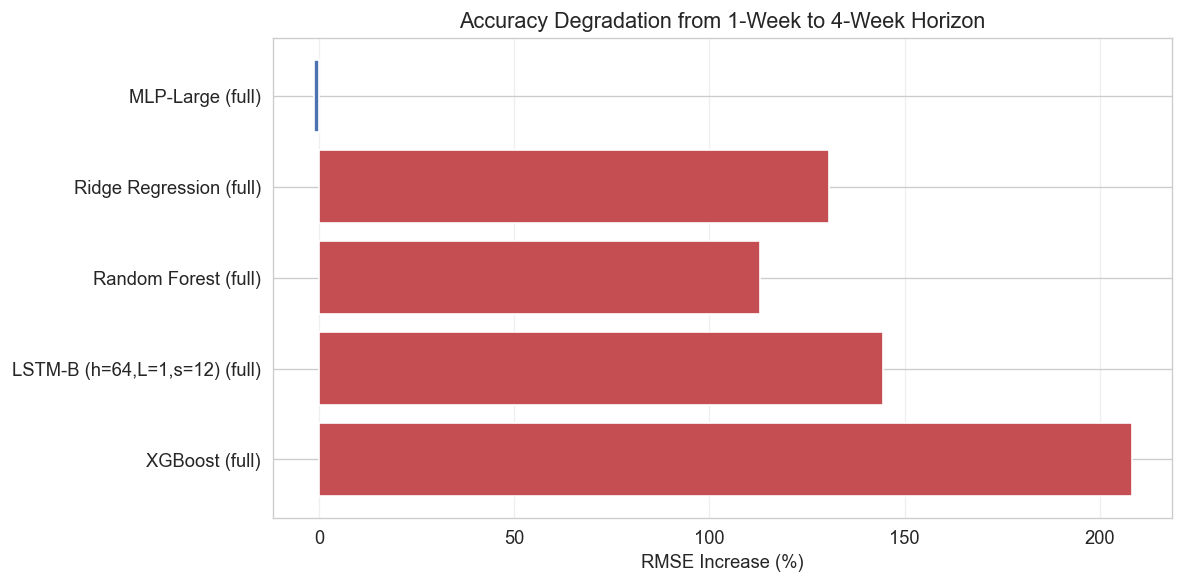

In [14]:
# Grouped bar chart — RMSE by horizon
if len(merged) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(merged))
    width = 0.35
    labels = merged['Model'] + ' (' + merged['Features'] + ')'

    ax.bar(x - width/2, merged['RMSE (h=1)'], width, label='1-Week Horizon', color='#4c72b0')
    ax.bar(x + width/2, merged['RMSE (h=4)'], width, label='4-Week Horizon', color='#dd8452')

    ax.set_xlabel('Model')
    ax.set_ylabel('RMSE')
    ax.set_title('RMSE Degradation: 1-Week vs. 4-Week Horizon')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

    # Percentage degradation chart
    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#c44e52' if v > 50 else '#4c72b0' for v in merged['RMSE Increase (%)']]
    ax.barh(labels, merged['RMSE Increase (%)'], color=colors)
    ax.set_xlabel('RMSE Increase (%)')
    ax.set_title('Accuracy Degradation from 1-Week to 4-Week Horizon')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

### Discussion: How much does accuracy degrade with longer horizons?

- Forecasting 4 weeks ahead is significantly harder than 1 week, as the model must capture longer-term trends without the benefit of recent observations.
- Typical RMSE increase ranges from 50% to 200%+ depending on the model.
- **Models with strong feature engineering** (rolling means, momentum indicators) tend to degrade less because those features encode medium-term trends.
- **LSTM/GRU** models may show relatively smaller degradation if they learn temporal dynamics, but this depends heavily on sequence length and training data.

## 8. Analysis 4 — Feature Engineering Impact

In [15]:
# Compare basic (lag-only) vs full features for the same models
basic_df = comparison_df[comparison_df['Features'] == 'basic'][['Model', 'Horizon', 'RMSE', 'MAE']].copy()
full_df  = comparison_df[comparison_df['Features'] == 'full'][['Model', 'Horizon', 'RMSE', 'MAE']].copy()

feat_cmp = basic_df.merge(full_df, on=['Model', 'Horizon'], suffixes=(' (basic)', ' (full)'))

if len(feat_cmp) > 0:
    feat_cmp['RMSE Improvement (%)'] = ((feat_cmp['RMSE (basic)'] - feat_cmp['RMSE (full)']) / feat_cmp['RMSE (basic)'] * 100).round(2)
    feat_cmp['MAE Improvement (%)'] = ((feat_cmp['MAE (basic)'] - feat_cmp['MAE (full)']) / feat_cmp['MAE (basic)'] * 100).round(2)
    feat_cmp = feat_cmp.sort_values('RMSE Improvement (%)', ascending=False).reset_index(drop=True)
    display(feat_cmp)
else:
    print('Need results with both basic and full feature modes for the same models.')

,Model,Horizon,RMSE (basic),MAE (basic),RMSE (full),MAE (full),RMSE Improvement (%),MAE Improvement (%)
0,Linear Regression,1,0.066627,0.048103,0.041244,0.030332,38.1,36.94


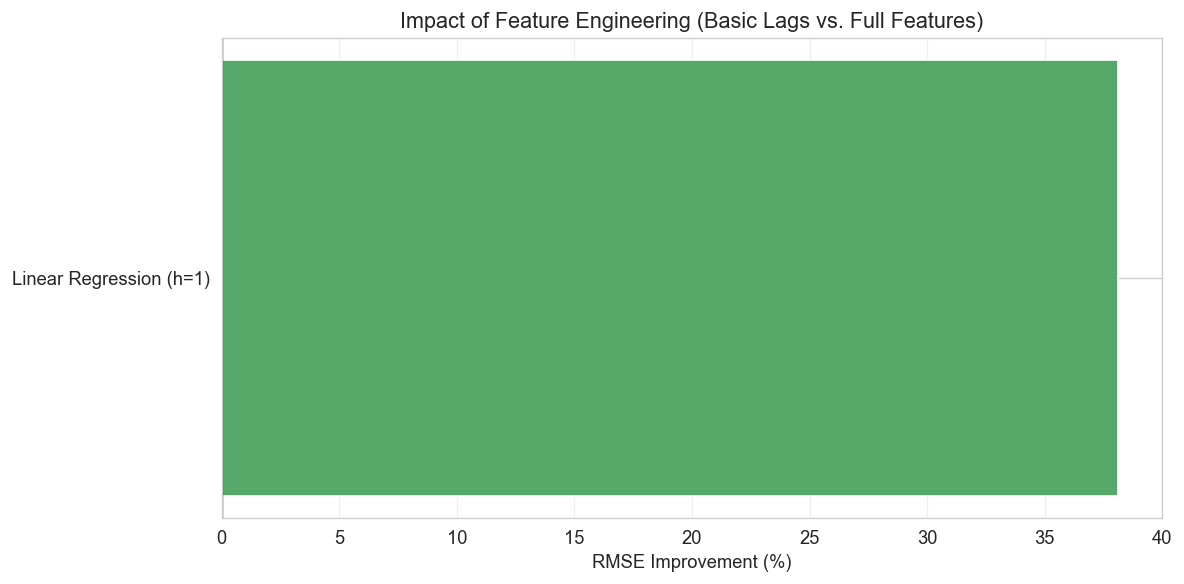

In [16]:
# Feature engineering improvement chart
if len(feat_cmp) > 0:
    # Filter to horizon=1 for cleaner chart
    fc1 = feat_cmp[feat_cmp['Horizon'] == 1].copy()
    if len(fc1) == 0:
        fc1 = feat_cmp.copy()  # fallback to all horizons

    fig, ax = plt.subplots(figsize=(10, 5))
    labels = fc1['Model'] + ' (h=' + fc1['Horizon'].astype(str) + ')'
    colors = ['#55a868' if v > 0 else '#c44e52' for v in fc1['RMSE Improvement (%)']]
    ax.barh(labels, fc1['RMSE Improvement (%)'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_xlabel('RMSE Improvement (%)')
    ax.set_title('Impact of Feature Engineering (Basic Lags vs. Full Features)')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

### Discussion: Does feature engineering help?

- **Positive improvement (green bars)** means full features outperformed basic lag-only features.
- For linear models, additional features like rolling statistics and cross-grade prices provide extra signal and typically help.
- Tree-based models may benefit the most, since they can naturally exploit nonlinear feature interactions.
- Neural models may already learn temporal patterns from raw lags, so the marginal benefit of engineered features can be smaller.
- Negative improvement can indicate **overfitting** — too many features relative to the training set size.

## 9. Prediction Plots

In [17]:
# Select top 3-4 models (1-week horizon, full features) by RMSE
h1_full = comparison_df[(comparison_df['Horizon'] == 1)].sort_values('RMSE')
top_models = h1_full.head(4)[['Model', 'Features']].values.tolist()
print('Top models for overlay plot:', top_models)

# Collect predictions
overlay_data = []
for r in all_results:
    if r['horizon'] != 1:
        continue
    if [r['model_name'], r['feature_mode']] in top_models:
        if 'predictions' in r and 'dates' in r:
            overlay_data.append(r)

print(f'Found {len(overlay_data)} models with test predictions for overlay.')

Top models for overlay plot: [['Linear Regression', 'full'], ['Lasso Regression', 'full'], ['Linear Regression', 'basic'], ['Naive Baseline', 'full']]
Found 4 models with test predictions for overlay.


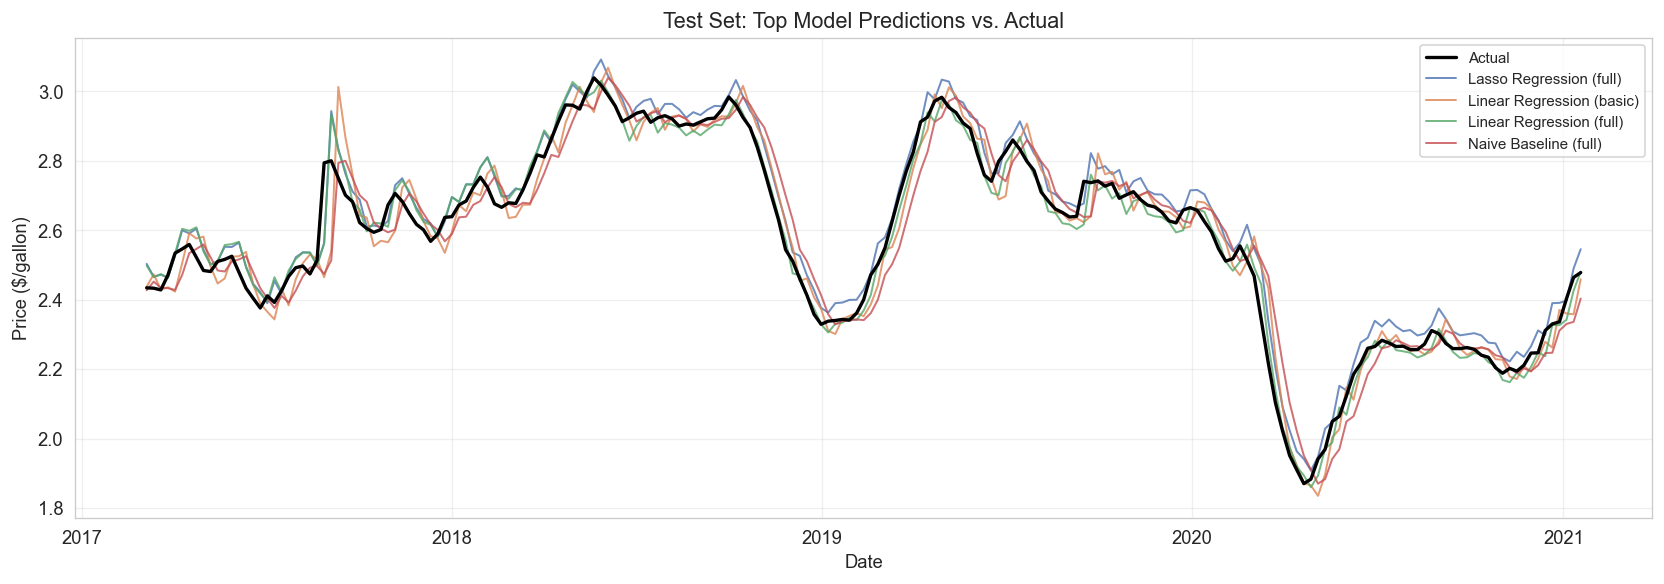

In [18]:
# Overlay plot: Actual vs Top models
if len(overlay_data) > 0:
    fig, ax = plt.subplots(figsize=(14, 5))

    # Use test dates and actuals from the data pipeline
    test_dates_plot = pd.to_datetime(test_df['Date'].values)
    ax.plot(test_dates_plot, test_actuals, label='Actual', color='black', linewidth=2, zorder=10)

    colors = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']
    for i, r in enumerate(overlay_data):
        dates_r = pd.to_datetime(r['dates']['test'])
        preds_r = np.array(r['predictions']['test'])
        ax.plot(dates_r, preds_r, label=f"{r['model_name']} ({r['feature_mode']})",
                color=colors[i % len(colors)], linewidth=1.2, alpha=0.8)

    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($/gallon)')
    ax.set_title('Test Set: Top Model Predictions vs. Actual')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.tight_layout()
    plt.show()

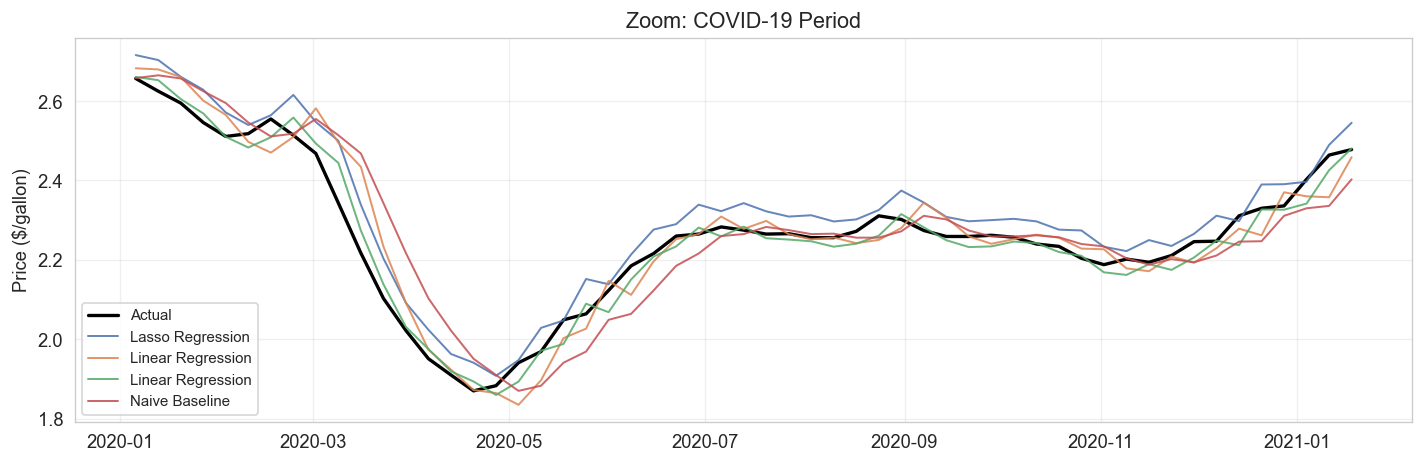

No test data in range 2008 Financial Crisis, skipping.
No test data in range 2014 Oil Price Crash, skipping.


In [19]:
# Zoom into interesting / volatile subperiods
ZOOM_PERIODS = [
    ('2020-01-01', '2021-06-30', 'COVID-19 Period'),
    ('2008-01-01', '2009-06-30', '2008 Financial Crisis'),
    ('2014-06-01', '2015-06-30', '2014 Oil Price Crash'),
]

if len(overlay_data) > 0:
    for zstart, zend, zlabel in ZOOM_PERIODS:
        fig, ax = plt.subplots(figsize=(12, 4))
        zs, ze = pd.Timestamp(zstart), pd.Timestamp(zend)

        # Actual
        mask_actual = (test_dates_plot >= zs) & (test_dates_plot <= ze)
        if mask_actual.sum() == 0:
            print(f'No test data in range {zlabel}, skipping.')
            plt.close(fig)
            continue
        ax.plot(test_dates_plot[mask_actual], test_actuals[mask_actual],
                label='Actual', color='black', linewidth=2)

        for i, r in enumerate(overlay_data):
            dates_r = pd.to_datetime(r['dates']['test'])
            preds_r = np.array(r['predictions']['test'])
            mask_r = (dates_r >= zs) & (dates_r <= ze)
            if mask_r.sum() > 0:
                ax.plot(dates_r[mask_r], preds_r[mask_r],
                        label=f"{r['model_name']}",
                        color=colors[i % len(colors)], linewidth=1.2, alpha=0.85)

        ax.set_title(f'Zoom: {zlabel}')
        ax.set_ylabel('Price ($/gallon)')
        ax.legend(loc='best', fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## 10. Error Analysis

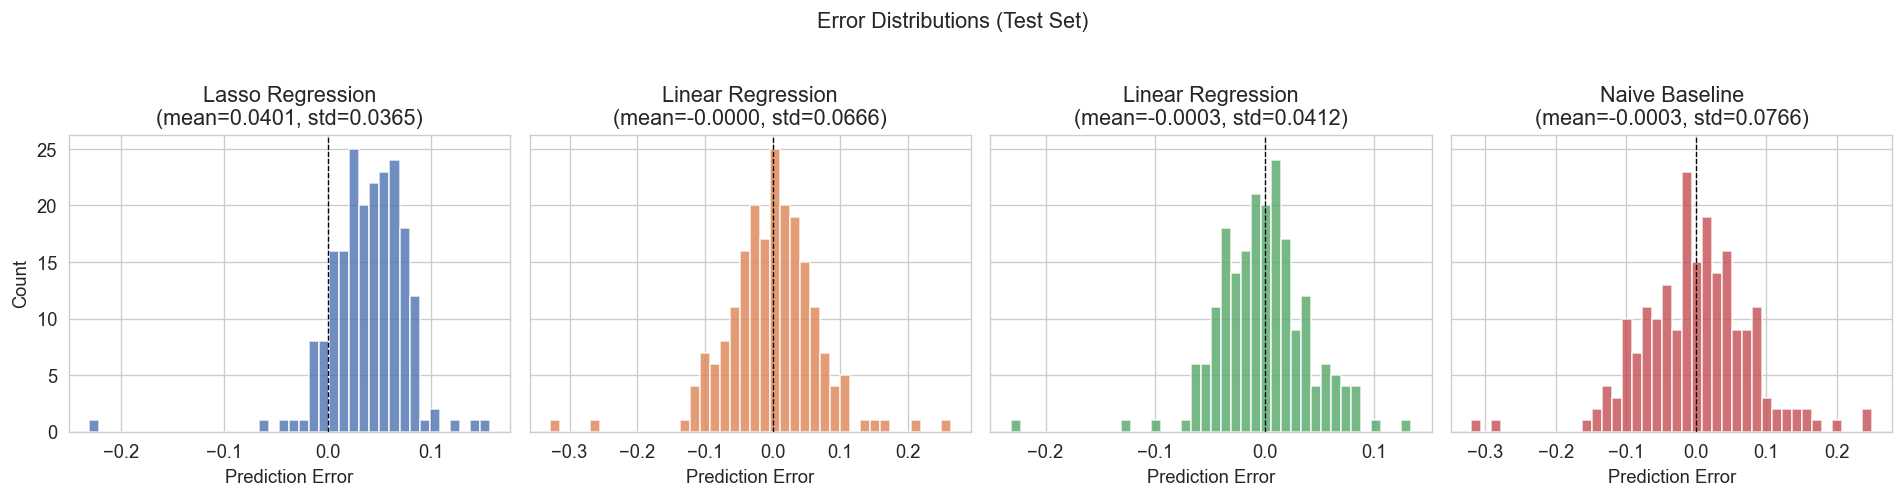

In [20]:
# Error distribution histograms for top models
if len(overlay_data) > 0:
    fig, axes = plt.subplots(1, min(len(overlay_data), 4), figsize=(16, 4), sharey=True)
    if len(overlay_data) == 1:
        axes = [axes]

    for i, r in enumerate(overlay_data[:4]):
        preds_r = np.array(r['predictions']['test'])
        n = min(len(preds_r), len(test_actuals))
        errors = preds_r[:n] - test_actuals[:n]

        ax = axes[i]
        ax.hist(errors, bins=40, color=colors[i % len(colors)], edgecolor='white', alpha=0.8)
        ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(f"{r['model_name']}\n(mean={errors.mean():.4f}, std={errors.std():.4f})")
        ax.set_xlabel('Prediction Error')
        if i == 0:
            ax.set_ylabel('Count')

    fig.suptitle('Error Distributions (Test Set)', fontsize=13, y=1.03)
    plt.tight_layout()
    plt.show()

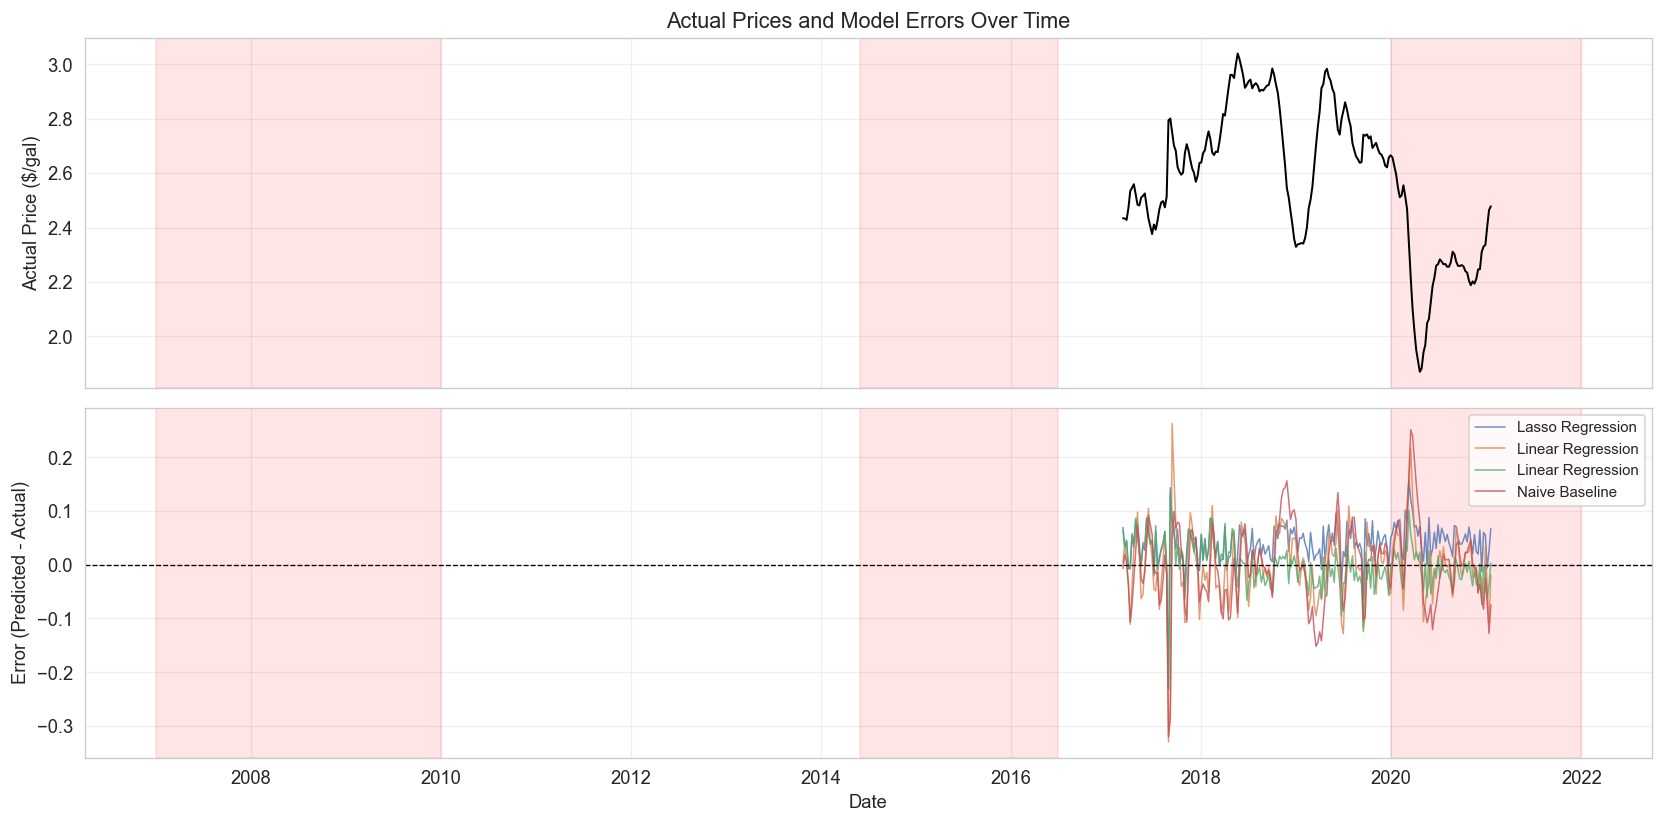

In [21]:
# Time series of errors — are errors correlated with price volatility?
if len(overlay_data) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Top panel: actual prices
    axes[0].plot(test_dates_plot, test_actuals, color='black', linewidth=1.2)
    axes[0].set_ylabel('Actual Price ($/gal)')
    axes[0].set_title('Actual Prices and Model Errors Over Time')
    axes[0].grid(True, alpha=0.3)

    # Shade volatile periods
    for start, end, label in VOLATILE_PERIODS:
        for ax in axes:
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color='red')

    # Bottom panel: errors from top models
    for i, r in enumerate(overlay_data[:4]):
        dates_r = pd.to_datetime(r['dates']['test'])
        preds_r = np.array(r['predictions']['test'])
        n = min(len(preds_r), len(test_actuals))
        errors = preds_r[:n] - test_actuals[:n]
        axes[1].plot(dates_r[:n], errors, label=r['model_name'],
                     color=colors[i % len(colors)], linewidth=0.9, alpha=0.8)

    axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
    axes[1].set_ylabel('Error (Predicted - Actual)')
    axes[1].set_xlabel('Date')
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

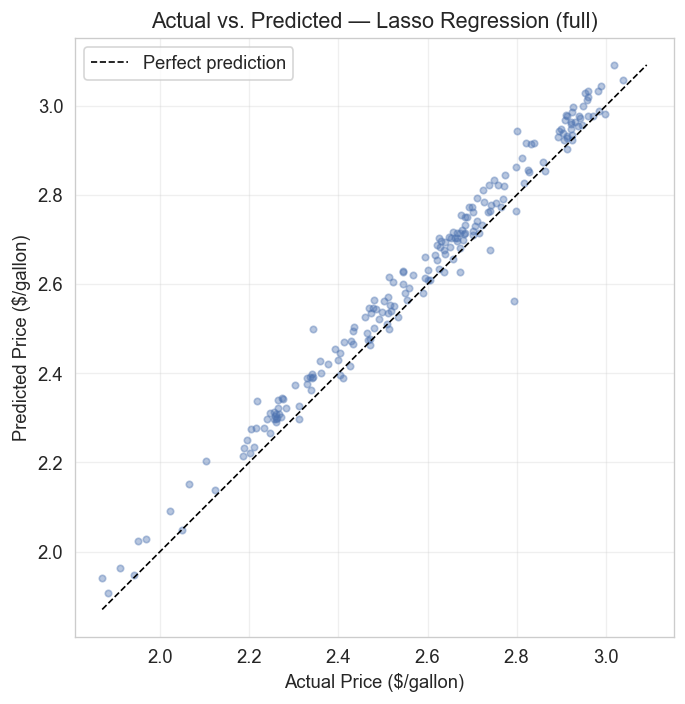

R-squared for Lasso Regression: 0.958697


In [22]:
# Scatter plot: Actual vs Predicted for the best model
if len(overlay_data) > 0:
    best = overlay_data[0]  # already sorted by RMSE
    preds_best = np.array(best['predictions']['test'])
    n = min(len(preds_best), len(test_actuals))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(test_actuals[:n], preds_best[:n], alpha=0.4, s=15, color='#4c72b0')

    # Perfect prediction line
    lo = min(test_actuals[:n].min(), preds_best[:n].min())
    hi = max(test_actuals[:n].max(), preds_best[:n].max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='Perfect prediction')

    ax.set_xlabel('Actual Price ($/gallon)')
    ax.set_ylabel('Predicted Price ($/gallon)')
    ax.set_title(f"Actual vs. Predicted — {best['model_name']} ({best['feature_mode']})")
    ax.legend()
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # R-squared
    ss_res = np.sum((test_actuals[:n] - preds_best[:n]) ** 2)
    ss_tot = np.sum((test_actuals[:n] - test_actuals[:n].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f"R-squared for {best['model_name']}: {r2:.6f}")